<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Aula 1: Gradiente Descendente</h1>
<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/NumPy-013243?style=for-the-badge&logo=numpy&logoColor=white"/>
</div>

---

## <span style="color:#1E90FF;">Motivação</span>

Na Aula 0 encontramos a reta escolhendo **dois pontos manualmente**. O resultado depende dos pontos escolhidos.

**Pergunta:** Existe uma reta que é *objetivamente melhor* do que todas as outras para um conjunto de dados?

**Resposta:** Sim — é a que **minimiza o erro total** entre as predições e os valores reais. Nesta aula vamos construir um algoritmo que encontra automaticamente esses parâmetros ótimos, usando apenas **NumPy**.

---
## <span style="color:#1E90FF;">1. Função de Perda (Loss)</span>

Para medir o quão boa é uma reta, calculamos o **Erro Quadrático Médio (MSE — Mean Squared Error)**:

$$\mathcal{L}(\beta_0, \beta_1) = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \beta_0 - \beta_1 \cdot t_i \right)^2$$

- $y_i$: valor real
- $\hat{y}_i = \beta_0 + \beta_1 \cdot t_i$: predição do modelo
- $n$: número de amostras

Quanto **menor** o MSE, melhor o ajuste. Nosso objetivo é encontrar $\beta_0$ e $\beta_1$ que **minimizem** essa função.

---
## <span style="color:#1E90FF;">2. Gradiente — A Direção do Erro Crescente</span>

O **gradiente** de $\mathcal{L}$ indica em qual direção os parâmetros devem se mover para **aumentar** o erro. Para minimizar, andamos na direção **oposta** ao gradiente.

Calculando as derivadas parciais:

$$\frac{\partial \mathcal{L}}{\partial \beta_0} = \frac{-2}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)$$

$$\frac{\partial \mathcal{L}}{\partial \beta_1} = \frac{-2}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right) \cdot t_i$$

**Intuição geométrica:** o gradiente aponta "morro acima"; nós queremos descer o morro.

---
## <span style="color:#1E90FF;">3. O Algoritmo: Gradiente Descendente</span>

A cada iteração (passo), atualizamos os parâmetros subtraindo o gradiente multiplicado pela **taxa de aprendizado** $\alpha$:

$$\beta_0 \leftarrow \beta_0 - \alpha \cdot \frac{\partial \mathcal{L}}{\partial \beta_0}$$

$$\beta_1 \leftarrow \beta_1 - \alpha \cdot \frac{\partial \mathcal{L}}{\partial \beta_1}$$

| Parâmetro | Papel |
|---|---|
| $\alpha$ (learning rate) | Tamanho do passo a cada iteração |
| Iterações | Quantas vezes repetimos a atualização |
| Ponto inicial | Valores iniciais de $\beta_0$ e $\beta_1$ (geralmente 0) |

> **$\alpha$ muito grande:** o algoritmo oscila e pode divergir.  
> **$\alpha$ muito pequeno:** converge lentamente.

---
## <span style="color:#1E90FF;">4. Implementação em NumPy</span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gradiente_descendente(t, y, alpha=0.01, n_iter=1000):
    """
    Regressão linear por gradiente descendente.

    Parâmetros
    ----------
    t      : array (n,) — variável de entrada (tempo)
    y      : array (n,) — variável alvo (eficiência)
    alpha  : float      — taxa de aprendizado
    n_iter : int        — número de iterações

    Retorna
    -------
    beta0, beta1 : parâmetros ajustados
    historico    : lista com o MSE a cada iteração
    """
    n = len(y)
    beta0 = 0.0
    beta1 = 0.0
    historico = []

    for _ in range(n_iter):
        # Predição atual
        y_pred = beta0 + beta1 * t

        # Erro (resíduos)
        residuo = y - y_pred

        # MSE atual
        mse = np.mean(residuo ** 2)
        historico.append(mse)

        # Gradientes
        grad_b0 = (-2 / n) * np.sum(residuo)
        grad_b1 = (-2 / n) * np.sum(residuo * t)

        # Atualização dos parâmetros
        beta0 = beta0 - alpha * grad_b0
        beta1 = beta1 - alpha * grad_b1

    return beta0, beta1, historico

print("Função `gradiente_descendente` implementada com sucesso.")

Função `gradiente_descendente` implementada com sucesso.


---
## <span style="color:#1E90FF;">5. Verificação com Dados Sintéticos</span>

Antes de aplicar ao problema real, vamos verificar o algoritmo com dados onde **já sabemos a resposta**: geraremos pontos de uma reta conhecida e verificamos se o gradiente descendente recupera os parâmetros corretos.

In [ ]:
import pandas as pd

# Parâmetros verdadeiros (que queremos recuperar)
BETA0_REAL = 5.0
BETA1_REAL = 2.3

np.random.seed(42)
n = 200
t_sin = np.linspace(0, 10, n)
y_sin = BETA0_REAL + BETA1_REAL * t_sin + np.random.normal(0, 0.5, n)  # reta + ruído

# Normalizar t para estabilizar o gradiente
t_norm = (t_sin - t_sin.mean()) / t_sin.std()

b0, b1, hist = gradiente_descendente(t_norm, y_sin, alpha=0.05, n_iter=500)

# Desnormalizar β₁ para escala original
b1_orig = b1 / t_sin.std()
b0_orig = b0 - b1_orig * t_sin.mean()

df_verif = pd.DataFrame(
    {
        "Verdadeiro": [BETA0_REAL, BETA1_REAL],
        "Recuperado": [b0_orig,    b1_orig],
    },
    index=["β₀", "β₁"],
)

display(df_verif.style
    .format("{:.4f}")
    .set_caption(f"MSE final: {hist[-1]:.6f}")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "1em"), ("font-weight", "bold"), ("color", "#1E90FF")]},
        {"selector": "th",
         "props": [("background-color", "#1E90FF"), ("color", "white"), ("text-align", "center")]},
        {"selector": "td",
         "props": [("text-align", "right"), ("padding", "6px 16px")]},
    ])
)

---
## <span style="color:#1E90FF;">6. Convergência do Erro</span>

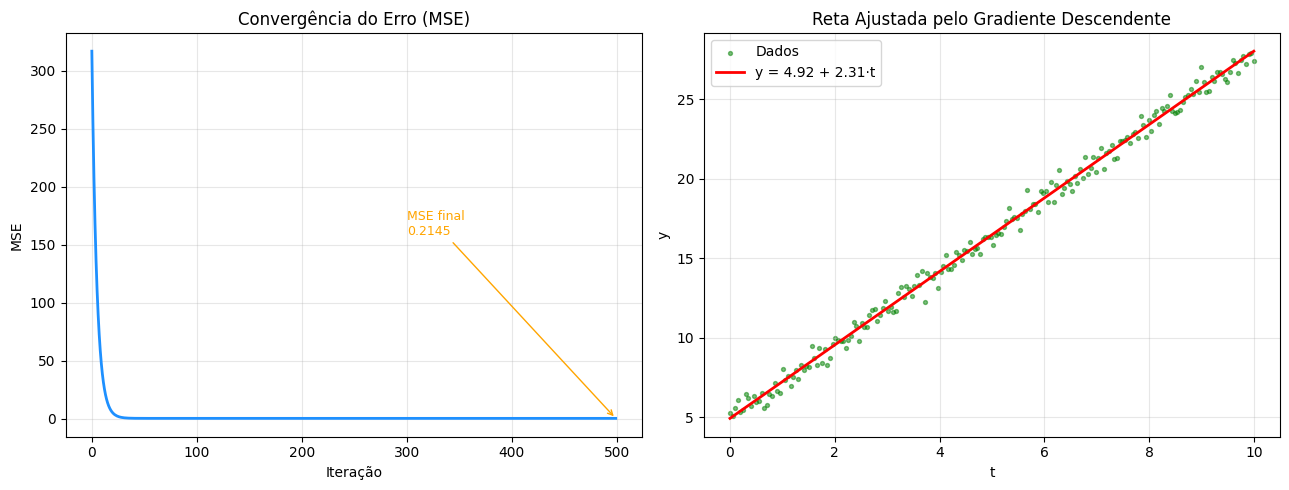

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Gráfico 1: curva de perda ---
axes[0].plot(hist, color="#1E90FF", linewidth=2)
axes[0].set_xlabel("Iteração")
axes[0].set_ylabel("MSE")
axes[0].set_title("Convergência do Erro (MSE)")
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f"MSE final\n{hist[-1]:.4f}",
                 xy=(len(hist)-1, hist[-1]),
                 xytext=(len(hist)*0.6, hist[0]*0.5),
                 arrowprops=dict(arrowstyle="->", color="orange"),
                 color="orange", fontsize=9)

# --- Gráfico 2: ajuste ---
y_fit = b0_orig + b1_orig * t_sin
axes[1].scatter(t_sin, y_sin, s=8, alpha=0.5, color="green", label="Dados")
axes[1].plot(t_sin, y_fit, color="red", linewidth=2,
             label=f"y = {b0_orig:.2f} + {b1_orig:.2f}·t")
axes[1].set_xlabel("t")
axes[1].set_ylabel("y")
axes[1].set_title("Reta Ajustada pelo Gradiente Descendente")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">7. Efeito da Taxa de Aprendizado</span>

A escolha de $\alpha$ é crucial: vamos visualizar o que acontece com valores muito grandes, adequados e muito pequenos.

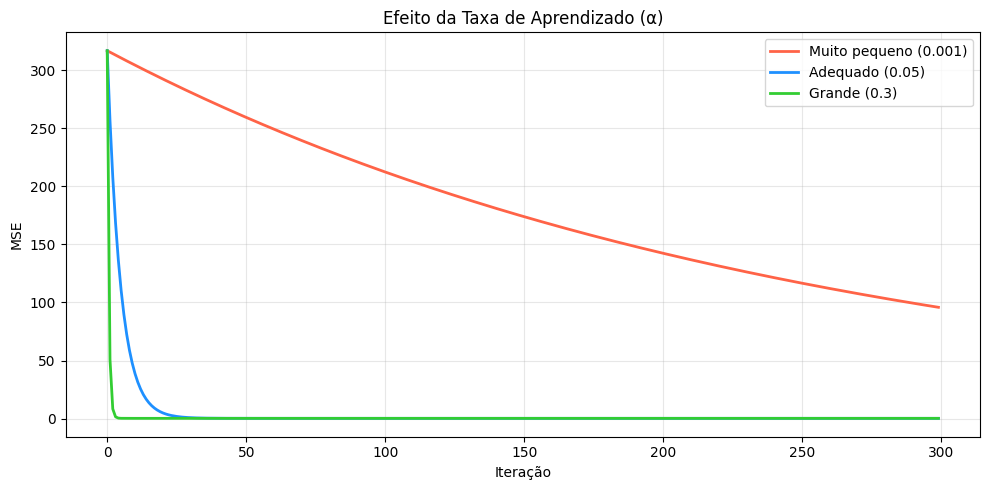

In [4]:
alphas = {"Muito pequeno (0.001)": 0.001,
          "Adequado (0.05)": 0.05,
          "Grande (0.3)": 0.3}

fig, ax = plt.subplots(figsize=(10, 5))

cores = ["#FF6347", "#1E90FF", "#32CD32"]
for (nome, alpha), cor in zip(alphas.items(), cores):
    _, _, h = gradiente_descendente(t_norm, y_sin, alpha=alpha, n_iter=300)
    # Clipa valores explosivos para manter o gráfico legível
    h_clip = [min(v, hist[0] * 2) for v in h]
    ax.plot(h_clip, color=cor, linewidth=2, label=nome)

ax.set_xlabel("Iteração")
ax.set_ylabel("MSE")
ax.set_title("Efeito da Taxa de Aprendizado (α)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">8. Resumo</span>

| Conceito | Descrição |
|---|---|
| **Loss (MSE)** | Mede o erro médio quadrático entre predição e valor real |
| **Gradiente** | Derivada da loss — indica a direção do crescimento do erro |
| **Gradiente Descendente** | Atualiza parâmetros na direção *oposta* ao gradiente |
| **Taxa de aprendizado α** | Controla o tamanho do passo a cada iteração |
| **Convergência** | O erro estabiliza quando os parâmetros chegam perto do ótimo |

### Implementação (3 linhas essenciais)

```python
y_pred = beta0 + beta1 * t                        # predição
grad_b0 = (-2/n) * np.sum(y - y_pred)             # gradiente β₀
grad_b1 = (-2/n) * np.sum((y - y_pred) * t)       # gradiente β₁
beta0 -= alpha * grad_b0                           # atualização
beta1 -= alpha * grad_b1
```

Na **Aula 2**, aplicaremos esse método exatamente ao problema do trocador de calor da Aula 0.